# The Transformation and Accept/Reject (aka. Von Neumann) methods 
Python notebook with exercise on how to generate random numbers following a specific PDF using uniformly distributed random numbers, in this case a third degree polynomial: $f(x) = x^3$, in the interval $[0, C]$ where $C$ is a number that ensures that the function if properly normalized.

Both the Accept-Reject (Von Neumann) and transformation method should be considered for the problem:
- Transformation method (if function can be integrated and then inverted).
- Accept-Reject (or Hit & Miss) method (by Ulam Stanislav and John Von Neumann).

### References:
- G. Cowan: Chapter 3
- P. R. Bevington: page 81-84
- __[40. Monte Carlo Techniques PDG](https://pdg.lbl.gov/2023/reviews/rpp2023-rev-monte-carlo-techniques.pdf)__

### Authors: 
- Troels C. Petersen (Niels Bohr Institute)

### Date:    
- 30-11-2025 (latest update)

***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit, cost
from scipy import stats
plt.rcParams['font.size'] = 18     # Set some basic plotting parameters

c:\Users\adamo\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


set the parameters of the program:

In [10]:
r = np.random
r.seed(42)

save_plots = False  
N_points = 10000      # Number of random points used 

xmin = 0
xmax = np.sqrt(2)            # Find out yourself what a good interval is.
N_bins = 100          # Find out yourself what a good number of bins is.

# f(x):
def fx_x3(x) :
    return x**3

In [11]:
# Define the numpy arrays to be filled:
x_transformation = np.zeros(N_points)
x_accepted       = np.zeros(N_points)

## Problem: 

1) Calculate $C$ such that f(x) is normalised [Analytical problem].

2) Calculate the relevant integral (below) and inverted function for using the transformation method. Check that the limits actually makes sense [Analytical problem]. Note that it is important to include the limits!

$$F(x) = \int_{-\infty}^{x} f(x') dx'$$

3) Produce random points following $f(x) = x^3$, in the interval $[0, C]$ using **both** the Transformation and the Accept/Reject method.

4) Fit your data with a third degree polynomial, and check that the coefficients correspond to what you would expect.

5) Now try to change the interval from [0,C] to [1,C], and see how the limits change.

## $0$ to $C$

In [ ]:
x_transformation = (4*r.random(N_points))**(1/4)   # Transformation method

Ntry = 0
for i in range(N_points):
    while True:
        Ntry += 1
        x2 = r.uniform(0, np.sqrt(2))
        y2 = r.uniform(0, np.sqrt(2)**3)
        if (y2 < x2**3 ):
            break      
    x_accepted[i] = x2

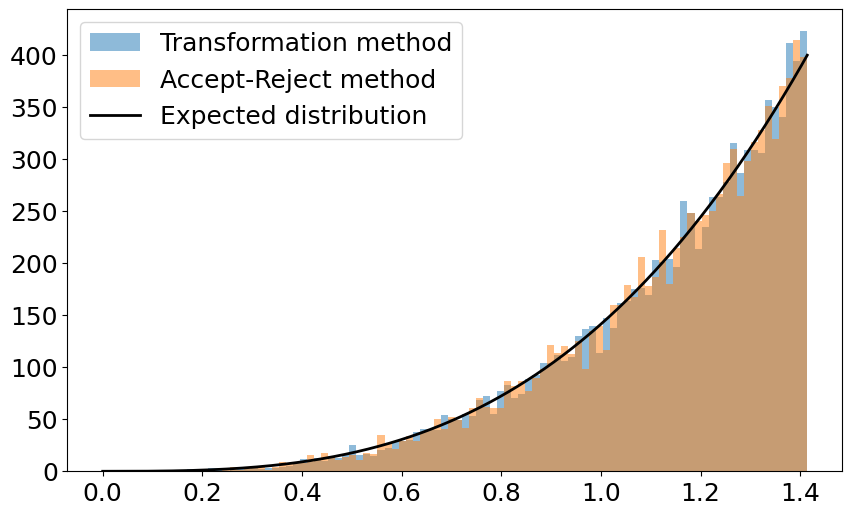

In [27]:
plt.figure(figsize=(10, 6))
bin_width = (xmax - xmin)/N_bins
plt.hist(x_transformation, bins=N_bins, range=(xmin, xmax),  histtype='stepfilled', alpha=0.5, label='Transformation method')
plt.hist(x_accepted, bins=N_bins, range=(xmin, xmax),        histtype='stepfilled', alpha=0.5, label='Accept-Reject method')
plt.plot(np.linspace(xmin, xmax, 1000), fx_x3(np.linspace(xmin, xmax, 1000))*N_points*bin_width, 'k-', linewidth=2.0, label='Expected distribution')
plt.legend()
plt.show()

In [ ]:
eff = N_points / Ntry
print(f"Efficiency of Accept-Reject method: {eff*100:5.2f} %")


Efficiency of Accept-Reject method: 25.29 %


In [36]:
# fit polynomial to data
def pol3_pdf(x, N, c0, c1, c2, c3):
    return (c0 + c1*x + c2*x*x + c3*x*x*x)

freq1, bins1 = np.histogram(x_transformation, bins=N_bins, range=(xmin, xmax))
x1 = (bins1[1:] + bins1[:-1])/2
mask = freq1 > 0
x1 = x1[mask]
y1 = freq1[mask]
sy1 = np.sqrt(y1)

fit_object1 = cost.LeastSquares(x1, y1, sy1, pol3_pdf)
minuit1 = Minuit(fit_object1, N=1000, c0=0.0, c1=0.0, c2=0.0, c3=1.0)
# minuit.errordef = 0.5
minuit1.migrad();

In [35]:
freq2, bins2 = np.histogram(x_transformation, bins=N_bins, range=(xmin, xmax))
x2 = (bins2[1:] + bins2[:-1])/2
mask = freq2 > 0
x2 = x2[mask]
y2 = freq2[mask]
sy2 = np.sqrt(y2)

fit_object2 = cost.LeastSquares(x2, y2, sy2, pol3_pdf)
minuit2 = Minuit(fit_object2, N=1000, c0=0.0, c1=0.0, c2=0.0, c3=1.0)
# minuit.errordef = 0.5
minuit2.migrad();

In [37]:
minuit = minuit2  # Choose which fit result to report
if (not minuit.fmin.is_valid) :                                   # Check if the fit converged!
    print("  WARNING: The chi2 fit DID NOT converge!!!")
minuit_output = [minuit.fmin, minuit.params]       # Save the output parameters in case needed
for name in minuit.parameters:
    print("  Chi2 Fit result: {0} = {1:.5f} +/- {2:.5f}".format(name, minuit.values[name], minuit.errors[name]))

  Chi2 Fit result: N = 1000.00000 +/- 0.00000
  Chi2 Fit result: c0 = 2.73509 +/- 0.00000
  Chi2 Fit result: c1 = -17.27228 +/- 0.00000
  Chi2 Fit result: c2 = 17.35286 +/- 0.00000
  Chi2 Fit result: c3 = 137.78580 +/- 0.00000


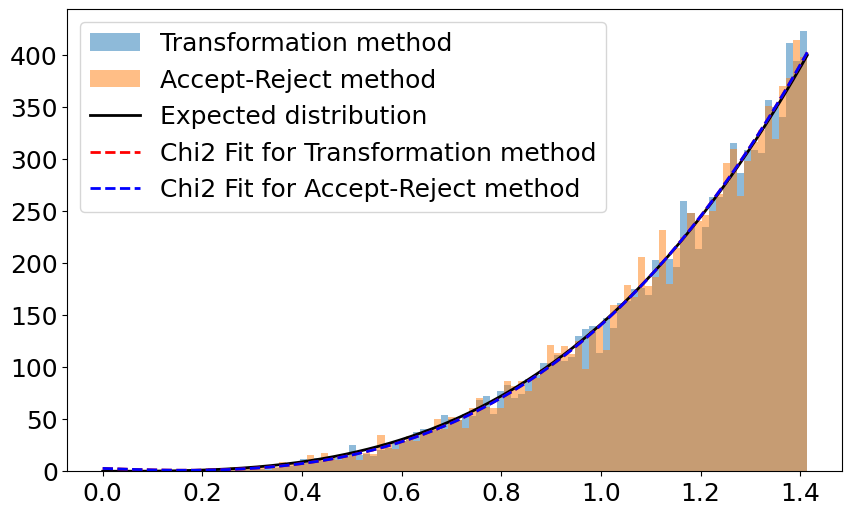

In [50]:
x_fit = np.linspace(xmin, xmax, 1000)
plt.figure(figsize=(10, 6))
bin_width = (xmax - xmin)/N_bins
plt.hist(x_transformation, bins=N_bins, range=(xmin, xmax),  histtype='stepfilled', alpha=0.5, label='Transformation method')
plt.hist(x_accepted, bins=N_bins, range=(xmin, xmax),        histtype='stepfilled', alpha=0.5, label='Accept-Reject method')
plt.plot(x_fit, fx_x3(x_fit)*N_points*bin_width, 'k-', linewidth=2.0, label='Expected distribution')
plt.plot(x_fit, pol3_pdf(x_fit, *minuit1.values), 'r--', linewidth=2.0, label='Chi2 Fit for Transformation method')
plt.plot(x_fit, pol3_pdf(x_fit, *minuit2.values), 'b--', linewidth=2.0, label='Chi2 Fit for Accept-Reject method')
plt.legend()
plt.show()


## From $1$ to $C$, with $C = \sqrt[4]{5}$

In [68]:
xmin = 1
xmax = np.sqrt(np.sqrt(5))
ymax = xmax**3
N_bins = 100          # Find out yourself what a good number of bins is.


x_transformation = (4*r.random(N_points)+1)**(1/4)   # Transformation method

Ntry = 0
for i in range(N_points):
    while True:
        Ntry += 1
        x2 = r.uniform(1, np.sqrt(np.sqrt(5)))
        y2 = r.uniform(0, np.sqrt(np.sqrt(5))**3)
        if (y2 < x2**3 ):
            break      
    x_accepted[i] = x2



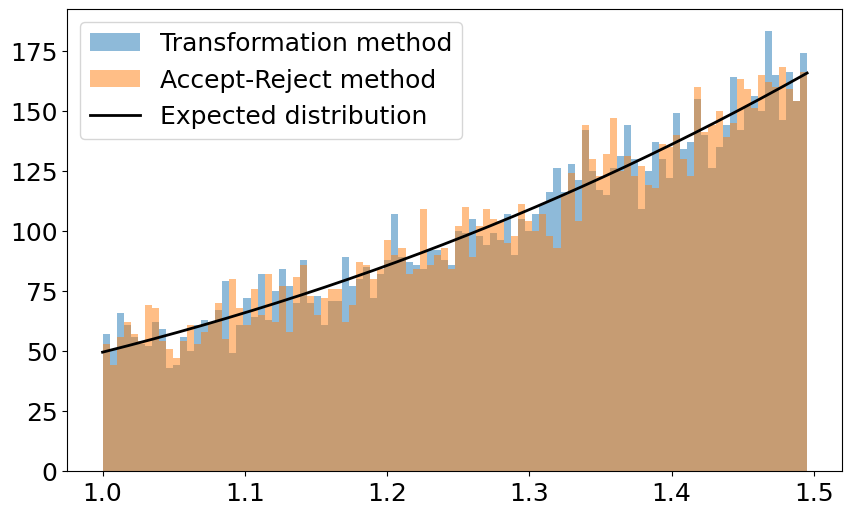

In [69]:
plt.figure(figsize=(10, 6))
bin_width = (xmax - xmin)/N_bins
plt.hist(x_transformation, bins=N_bins, range=(xmin, xmax),  histtype='stepfilled', alpha=0.5, label='Transformation method')
plt.hist(x_accepted, bins=N_bins, range=(xmin, xmax),        histtype='stepfilled', alpha=0.5, label='Accept-Reject method')
plt.plot(np.linspace(xmin, xmax, 1000), fx_x3(np.linspace(xmin, xmax, 1000))*N_points*bin_width, 'k-', linewidth=2.0, label='Expected distribution')
plt.legend()
plt.show()

In [70]:
# fit polynomial to data
def pol3_pdf(x, N, c0, c1, c2, c3):
    return (c0 + c1*x + c2*x*x + c3*x*x*x)

freq1, bins1 = np.histogram(x_transformation, bins=N_bins, range=(xmin, xmax))
x1 = (bins1[1:] + bins1[:-1])/2
mask = freq1 > 0
x1 = x1[mask]
y1 = freq1[mask]
sy1 = np.sqrt(y1)

fit_object1 = cost.LeastSquares(x1, y1, sy1, pol3_pdf)
minuit1 = Minuit(fit_object1, N=1000, c0=0.0, c1=0.0, c2=0.0, c3=1.0)
# minuit.errordef = 0.5
minuit1.migrad();

In [71]:
freq2, bins2 = np.histogram(x_transformation, bins=N_bins, range=(xmin, xmax))
x2 = (bins2[1:] + bins2[:-1])/2
mask = freq2 > 0
x2 = x2[mask]
y2 = freq2[mask]
sy2 = np.sqrt(y2)

fit_object2 = cost.LeastSquares(x2, y2, sy2, pol3_pdf)
minuit2 = Minuit(fit_object2, N=1000, c0=0.0, c1=0.0, c2=0.0, c3=1.0)
# minuit.errordef = 0.5
minuit2.migrad();

In [76]:
minuit = minuit2  # Choose which fit result to report
if (not minuit.fmin.is_valid) :                                   # Check if the fit converged!
    print("  WARNING: The chi2 fit DID NOT converge!!!")
minuit_output = [minuit.fmin, minuit.params]       # Save the output parameters in case needed
for name in minuit.parameters:
    print("  Chi2 Fit result: {0} = {1:.5f} +/- {2:.5f}".format(name, minuit.values[name], minuit.errors[name]))

  Chi2 Fit result: N = 1000.00458 +/- 0.00000
  Chi2 Fit result: c0 = 41.62099 +/- 0.00000
  Chi2 Fit result: c1 = -42.89302 +/- 0.00000
  Chi2 Fit result: c2 = -13.93560 +/- 0.00000
  Chi2 Fit result: c3 = 65.89752 +/- 0.00000


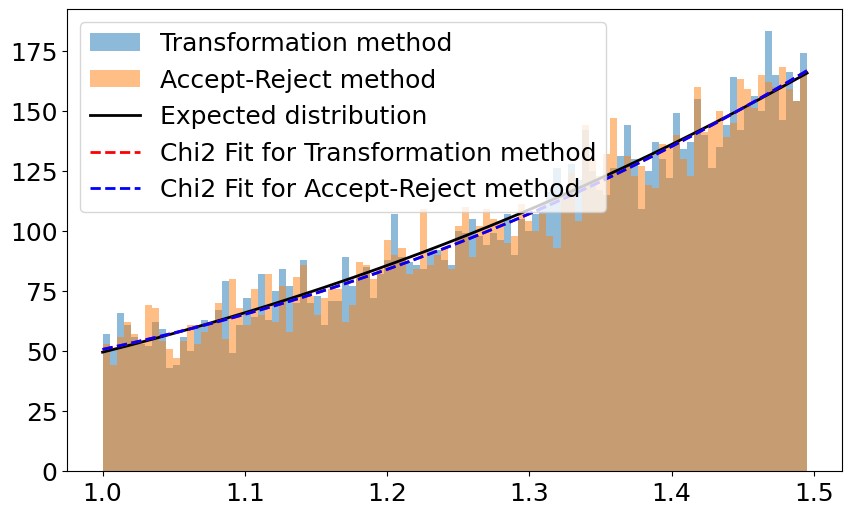

In [75]:
x_fit = np.linspace(xmin, xmax, 1000)
plt.figure(figsize=(10, 6))
bin_width = (xmax - xmin)/N_bins
plt.hist(x_transformation, bins=N_bins, range=(xmin, xmax),  histtype='stepfilled', alpha=0.5, label='Transformation method')
plt.hist(x_accepted, bins=N_bins, range=(xmin, xmax),        histtype='stepfilled', alpha=0.5, label='Accept-Reject method')
plt.plot(x_fit, fx_x3(x_fit)*N_points*bin_width, 'k-', linewidth=2.0, label='Expected distribution')
plt.plot(x_fit, pol3_pdf(x_fit, *minuit1.values), 'r--', linewidth=2.0, label='Chi2 Fit for Transformation method')
plt.plot(x_fit, pol3_pdf(x_fit, *minuit2.values), 'b--', linewidth=2.0, label='Chi2 Fit for Accept-Reject method')
plt.legend()
plt.show()


# Learning points:

As a basic principle, this exercise should make you capable of using two methods for generating random numbers according to a 1D PDF f(x) based on uniform random numbers (provided by a standard algorithm):
1. Transformation method (using integral+inverse of f(x))
2. Accept-Reject method (using sampling in 2D compared to f(x))

You should know:
1. The advantages and limitations of each method.
2. How to get the desired result out of each method.

Finally, you should understand the motivation behind generating random numbers according to a given distribution, namely for simulating complicated situations (e.g. experimental setup), and evaluating the outcome.